### Import Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/seaborn/_statistics.py:32: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.5.3)
  from scipy.stats import gaussian_kde


In [2]:
df = pd.read_csv("dataset/data_banknote_authentication.csv")
df.head()

,varianc,skewness,curtosis,entropy,class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


### Visualize Data

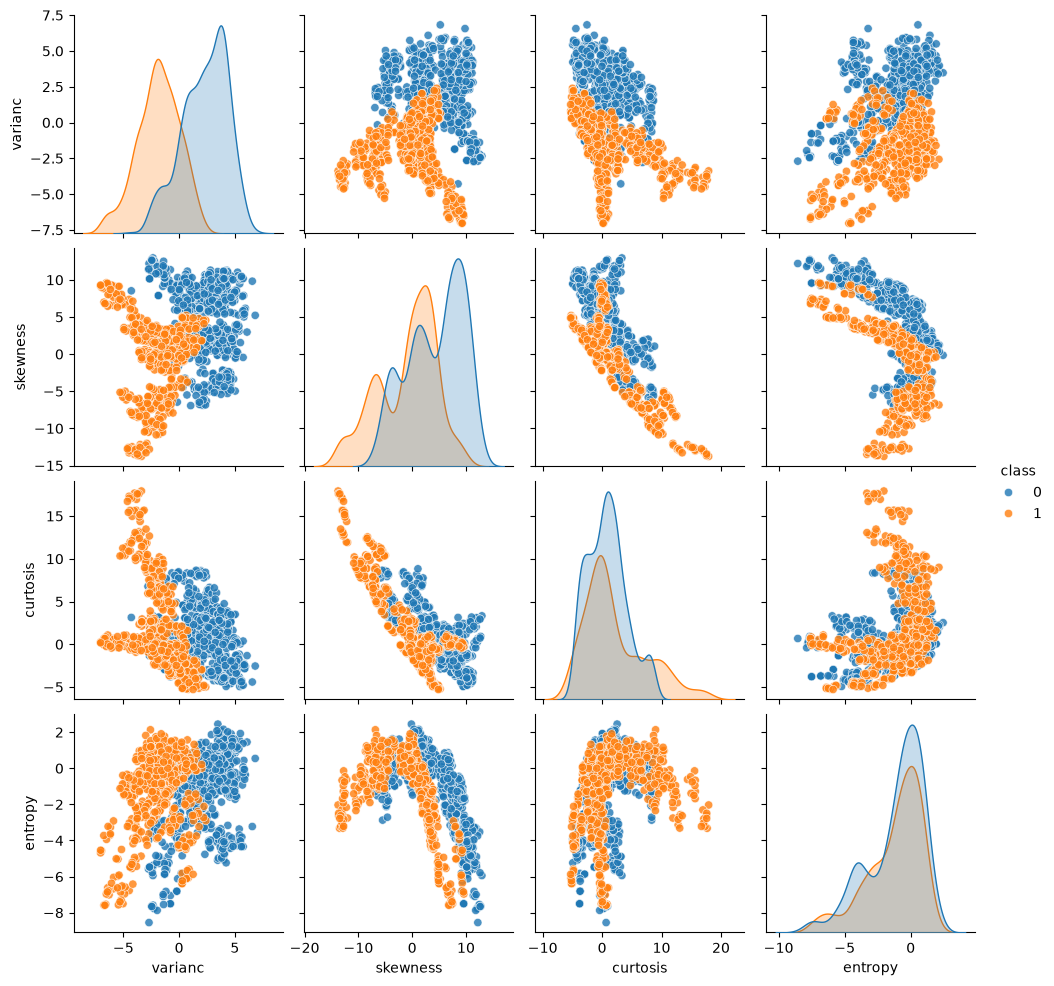

In [8]:
sns.pairplot(df, hue='class', plot_kws={'alpha': 0.8})
plt.show()

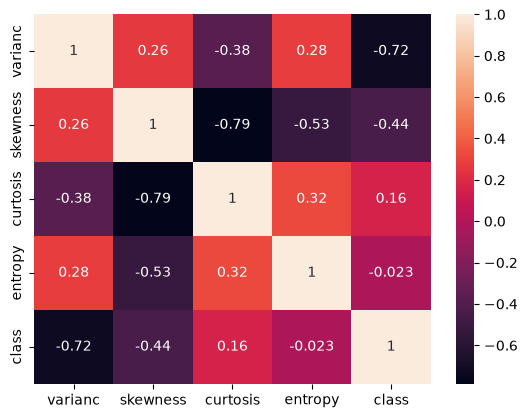

In [11]:
sns.heatmap(data=df.corr(), annot=True)
plt.show()

### Normalize Data

In [3]:
X = df.drop(['class'], axis=1)
y = df['class'].values

In [4]:
X_scaled = (X - np.mean(X.values, axis=0)) / np.std(X.values, axis=0)
y = np.where(y == 0, -1, 1)

### Slip Data

In [5]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size = 0.2, stratify = y)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((1097, 4), (275, 4), (1097,), (275,))

### Train Data

In [6]:
from clazz.Perceptron import Perceptron

perceptron = Perceptron(learning_rate=0.5, epochs=1000)
perceptron.fit(X_train, y_train)

### Predict Data

In [8]:
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score

In [11]:
y_pred = perceptron.predict(X_test)

In [10]:
print("Classication Report: \n",classification_report(y_test, y_pred))
acc = accuracy_score(y_test,y_pred)
print("Accuracy Score: ",acc*100,"%")

Classication Report: 
               precision    recall  f1-score   support

          -1       0.97      0.99      0.98       153
           1       0.98      0.97      0.98       122

    accuracy                           0.98       275
   macro avg       0.98      0.98      0.98       275
weighted avg       0.98      0.98      0.98       275

Accuracy Score:  97.81818181818181 %


In [12]:
y_pred = perceptron.predict(X_train)

In [13]:
print("Classication Report: \n",classification_report(y_train, y_pred))
acc = accuracy_score(y_train,y_pred)
print("Accuracy Score: ",acc*100,"%")

Classication Report: 
               precision    recall  f1-score   support

          -1       0.99      1.00      0.99       609
           1       0.99      0.99      0.99       488

    accuracy                           0.99      1097
   macro avg       0.99      0.99      0.99      1097
weighted avg       0.99      0.99      0.99      1097

Accuracy Score:  99.36189608021878 %
